# Comparison of blazars and ExB cumulative overdensity with galaxies in the catalog

In this notebook, we try to understand if the blazar cumulative overdensity distribution is similar to the one for general galaxies.

**General framework:**

1. Determine NSCat blazar and ExB distribution

2. Import the overdensities and establish an interpolator

3. According to that distribution, select randomly sources from the galactic catalogs (such that they are *uniform* within the sky)

4. Compare the distributions and find if the blazars (and ExBs) are typical objects or outliers 

## 1. NSCat blazar distribution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
import pandas as pd

from config.settings import DATA_DIR, OVD_DIR, FIG_DIR

from config.plotting import set_plotting_defaults
set_plotting_defaults()

In [2]:
nscat_file = DATA_DIR / "ns" / "NS_total.csv"
nscat = pd.read_csv(nscat_file, index_col=0)
nscat = nscat.query("z < 0.51")
nscat.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table
2,RX J0022.0+0006,5.515,0.113,5,9,1,1.66±0.12,0.306,BLL,NaN,2
3,SHBL J001355.9-185406,3.480,-18.912,2,2,1,1.9±0.08,0.095,BLL,E,1
5,PMN J0039-2220,9.778,-22.328,1,4,1,1.78±0.09,0.064,BLL,NaN,3
6,RBS 0723,131.812,11.569,2,2,0,1.77±0.06,0.198,BLL,E,1
8,1RXS J005117.7-624154,12.824,-62.704,2,5,1,1.77±0.02,0.156,BLL,NaN,2


In [3]:
ns_lowz = nscat.query("z < 0.18")

In [4]:
from scipy.ndimage import gaussian_filter1d

ns_hist, edges = np.histogram(nscat["z"], bins=17, range=[0.01, 0.52], density=True)
z_centers = 0.5 * (edges[1:] + edges[:-1])

# smooth
nz = gaussian_filter1d(ns_hist, sigma=1.0)

# normalize
nz /= np.trapz(nz, z_centers)

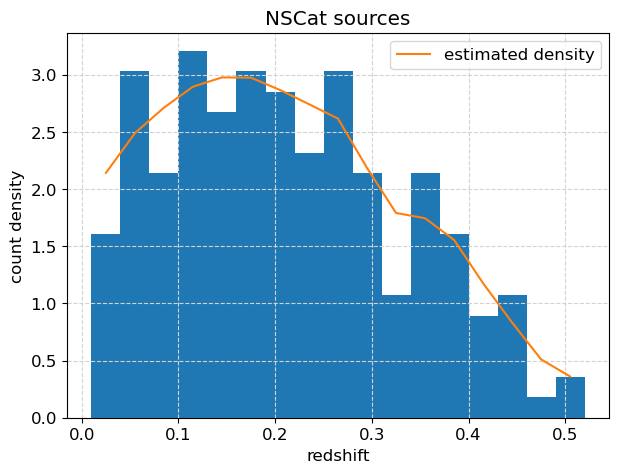

In [5]:
plt.hist(nscat["z"], bins=17, range=[0.01, 0.52], density=True)
plt.plot(z_centers, nz, label='estimated density')
plt.title("NSCat sources")
plt.xlabel("redshift")
plt.ylabel("count density")
plt.legend(loc=1)
plt.show()

## 2. Import overdensities and set the interpolator

In [6]:
import os
import healpy as hp
from scipy.interpolate import RegularGridInterpolator

In [7]:
def create_overdensity_interpolator(overdensity_dir, z_max=0.5):
    """
    Loads HEALPix overdensity maps from a directory, extends the grid boundaries 
    with zero-maps at z=0.0 and z=z_max, and builds a 2D RegularGridInterpolator.
    
    Parameters:
    -----------
    overdensity_dir : str
        Path to the directory containing the overdensity .npy files.
        Files are expected to follow the 'mapsXYZ-ABC...' naming convention.
    z_max : float
        The upper boundary redshift where the grid is extended with a zero map.
        
    Returns:
    --------
    zp_interpolator : scipy.interpolate.RegularGridInterpolator
        An interpolator instance that takes coordinates in the form (z, pixel_index).
    """
    # 1. Gather and sort files to ensure strict ascending order in redshift
    try:
        ovd_files = sorted([f for f in os.listdir(overdensity_dir) if f.endswith('.npy')])
    except FileNotFoundError:
        raise FileNotFoundError(f"The directory '{overdensity_dir}' does not exist.")
        
    if not ovd_files:
        raise ValueError(f"No .npy files found in '{overdensity_dir}'.")

    # 2. Extract redshift boundaries from filenames
    z_start = [float(f[4:7]) / 100.0 for f in ovd_files]
    z_end = [float(f[8:11]) / 100.0 for f in ovd_files]

    # 3. Load maps and extend the array with zero-maps at the boundaries
    maps_d = np.array([np.load(os.path.join(overdensity_dir, f)) for f in ovd_files])
    
    # Pre-allocate array with 2 extra slots for z=0.0 and z=z_max boundaries
    maps = np.zeros((maps_d.shape[0] + 2, maps_d.shape[1]))
    maps[1:-1] = maps_d

    # 4. Construct the redshift grid coordinate array
    z_data = np.zeros(len(z_start) + 2)
    z_data[1:-1] = 0.5 * (np.array(z_start) + np.array(z_end))
    z_data[-1] = z_max

    # 5. Construct the pixel grid coordinate array
    npix = maps_d.shape[1]
    pix_data = np.arange(0, npix, 1)

    # 6. Build and return the interpolator
    zp_interpolator = RegularGridInterpolator(
        (z_data, pix_data),
        maps,
        bounds_error=False,
        fill_value=0
    )
    
    return zp_interpolator

In [8]:
import numpy as np
import healpy as hp

def add_overdensity_values_to_catalog(catalog, interpolator, nside, z_min=0.00, z_max=0.6, num_points=100):
    """
    Computes cumulative overdensities using a global, shared redshift grid.
    For each galaxy, overdensity values at redshifts above its own z are set to 0.
    
    Works with both dictionaries and Pandas DataFrames.
    """
    z_arr = np.asarray(catalog['z'])
    ra_arr = np.asarray(catalog['RA'])
    dec_arr = np.asarray(catalog['Dec'])
    num_galaxies = len(z_arr)
    
    # 1. Get pixel indices
    pix_indices = hp.ang2pix(nside, ra_arr, dec_arr, lonlat=True)
    
    # 2. Define the FIXED global redshift grid (shared by all sources)
    # Shape: (num_points, 1)
    z_grid_global = np.linspace(z_min, z_max, num_points)[:, np.newaxis]
    
    # 3. Broadcast the global z-grid and pixel indices into 2D arrays
    # Both shapes will be: (num_points, num_galaxies)
    z_matrix = np.tile(z_grid_global, (1, num_galaxies))
    pix_matrix = np.tile(pix_indices, (num_points, 1))
    
    # 4. Query the interpolator in a vectorized batch
    query_coords = np.column_stack((z_matrix.ravel(), pix_matrix.ravel()))
    interpolated_values = interpolator(query_coords).reshape(num_points, num_galaxies)
    
    # 5. Apply your physical condition: zero out everything where z_grid > z_galaxy
    # z_arr is shape (num_galaxies,), which broadcasts perfectly across axis 0
    boundary_mask = z_matrix > z_arr
    interpolated_values[boundary_mask] = 0.0
    
    # 6. Integrate over the global, uniform z-grid
    # Since z_grid_global is uniform, axis=0 integration is perfectly stable
    integrated_values = np.trapz(interpolated_values, z_grid_global, axis=0)
    
    # 7. Normalize by the galaxy's redshift and store
    catalog['ovdvalue'] = integrated_values / z_arr
    
    print(f"Successfully calculated 'ovdvalue' for {num_galaxies} galaxies using the masked global grid.")

In [9]:
overdensity_interpolator = create_overdensity_interpolator(OVD_DIR)
add_overdensity_values_to_catalog(nscat, overdensity_interpolator, nside=128)

Successfully calculated 'ovdvalue' for 190 galaxies using the masked global grid.


In [10]:
nscat = nscat.sort_values('z')
nscat.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
14,M 82,148.947,69.667,1,3,1,2.21±0.03,0.001,SBG,NaN,1,0.000000
126,Centaurus A,201.381,-43.016,5,6,1,2.574±0.019,0.002,RDG,NaN,0,0.000000
115,M 87,187.712,12.388,5,7,0,2.064±0.028,0.004,RDG,NaN,0,0.000000
28,NGC 1275,49.958,41.512,11,12,1,2.123±0.005,0.017,RDG,NaN,0,0.154198
161,H 1722+119,261.271,11.875,8,10,2,1.869±0.019,0.018,BLL,NaN,0,-0.055214


In [11]:
nscat_prep = pd.read_csv(DATA_DIR / 'ns' / "ns_total_ovd.csv", index_col=0)

In [12]:
nscat_prep.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
14,M 82,148.947,69.667,1,3,1,2.21±0.03,0.001,SBG,NaN,1,0.000000
126,Centaurus A,201.381,-43.016,5,6,1,2.574±0.019,0.002,RDG,NaN,0,0.000000
115,M 87,187.712,12.388,5,7,0,2.064±0.028,0.004,RDG,NaN,0,0.000000
28,NGC 1275,49.958,41.512,11,12,1,2.123±0.005,0.017,RDG,NaN,0,0.212933
161,H 1722+119,261.271,11.875,8,10,2,1.869±0.019,0.018,BLL,NaN,0,-0.076245


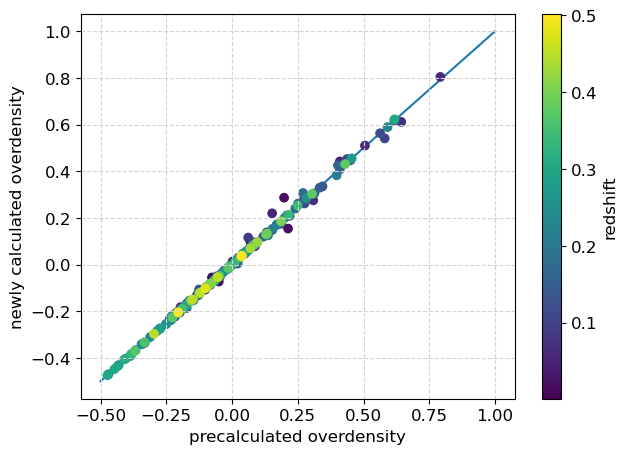

In [13]:
ovd = np.linspace(-0.5, 1.0, 100)
plt.plot(ovd, ovd, zorder=0)
plt.grid(linestyle='dashed', color='lightgray')
plt.scatter(nscat_prep['ovdvalue'], nscat['ovdvalue'], c=nscat['z'])
plt.colorbar(label='redshift')
plt.xlabel('precalculated overdensity')
plt.ylabel('newly calculated overdensity')
plt.show()

### Add EXTREME and LOWZ configurations

In [14]:
ns_extr = nscat.query('HSP == "E"')
ns_extr.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
157,Markarian 501,253.474,39.759,81,109,22,1.795±0.008,0.034,BLL,E,0,-0.061268
162,1ES 1727+502,262.078,50.227,5,11,4,1.785±0.022,0.055,BLL,E,0,-0.216988
169,PMN J1256-1146,194.063,-11.776,2,2,0,1.97±0.05,0.058,BLL,E,3,0.446928
68,PGC 2402248,113.362,51.880,3,5,1,1.769±0.079,0.065,BLL,E,0,0.137560
53,PKS 0548-322,87.625,-32.277,4,5,0,1.829±0.071,0.069,BLL,E,0,0.450114


In [15]:
ns_lowz = nscat.query('z < 0.18')
ns_lowz.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
14,M 82,148.947,69.667,1,3,1,2.21±0.03,0.001,SBG,NaN,1,0.000000
126,Centaurus A,201.381,-43.016,5,6,1,2.574±0.019,0.002,RDG,NaN,0,0.000000
115,M 87,187.712,12.388,5,7,0,2.064±0.028,0.004,RDG,NaN,0,0.000000
28,NGC 1275,49.958,41.512,11,12,1,2.123±0.005,0.017,RDG,NaN,0,0.154198
161,H 1722+119,261.271,11.875,8,10,2,1.869±0.019,0.018,BLL,NaN,0,-0.055214


## 3. Sampling from the galactic catalog

There are three possible techniques

**Idea 1.** Sample from 2MRS only as this is the lowest statistics catalog in the whole sky

**Idea 2.** Try combining catalogs in the sky

*Concern:* won't we be then constrained by the lowest statistics catalog?

**Idea 3.** Do it for each catalog separately and check

*Motivation* as filaments have to be small in the sky, and the catalogs are large enough, we shall not expect cosmic variance to strongly influence the results of this separate catalog survey

**WE PROCEED WITH IDEA 3, AS IT ANYWAY CONTAINTS IDEA 1**

### 2MRS vs NSCat

Both 2MRS, and 6dF have a few sources above $z = 0.3$, which means that we cannot sample data from them for higher redshifts effectively.

Because of that, we decided to organize selection for these two catalogs only for lower redshift objects: $z < 0.18$ and make the whole selection for BOSS only.

Thus, we recalculate the NSCat distribution for $z \in [0.1, 0.18]$

In [16]:
# ALL THE NSCat
ns_hist, edges = np.histogram(nscat["z"], bins=17, range=[0.01, 0.18], density=True)
z_centers = 0.5 * (edges[1:] + edges[:-1])

# smooth
nz = gaussian_filter1d(ns_hist, sigma=1.0)

# normalize
nz /= np.trapz(nz, z_centers)

In [17]:
# EXTREME BLAZARS ONLY
ns_extr_hist, edges = np.histogram(ns_extr["z"], bins=17, range=[0.01, 0.18], density=True)

# smooth
nz_extr = gaussian_filter1d(ns_extr_hist, sigma=1.0)

# normalize
nz_extr /= np.trapz(nz_extr, z_centers)

In [18]:
two_mrs_raw = np.load(DATA_DIR / "2mass" / "2mass-table.npz")

two_mrs = pd.DataFrame(np.array([two_mrs_raw["ra"], two_mrs_raw["dec"], two_mrs_raw["z"]]).T, columns=["RA", "Dec", "z"])

two_mrs.head()

,RA,Dec,z
0,10.68471,41.26875,-0.00300
1,11.88806,-25.28880,0.00243
2,148.88826,69.06526,-0.00034
3,201.36565,-43.01871,0.00547
4,196.36366,-49.46790,0.00563


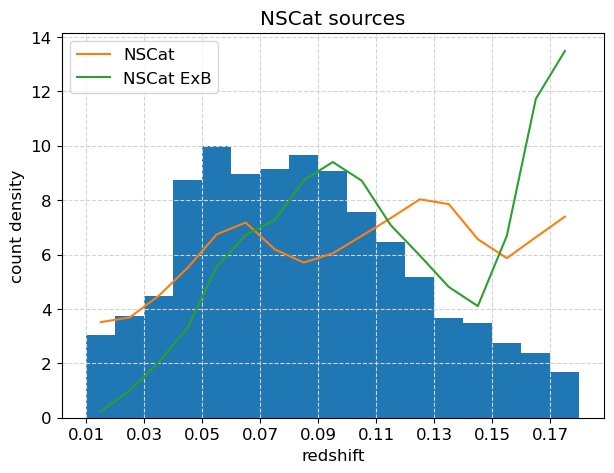

In [19]:
plt.hist(two_mrs["z"], bins=17, range=[0.01, 0.18], density=True)
plt.plot(z_centers, nz, label='NSCat')
plt.plot(z_centers, nz_extr, label='NSCat ExB')
plt.title("NSCat sources")
plt.xlabel("redshift")
plt.xticks(edges[::2])
plt.ylabel("count density")
plt.legend(loc=2)
plt.show()

In [20]:
def rejection_sample_from_target_dataset(source_redshifts, target_redshifts, z_min, z_max, n_bins=17):
    """
    Mathematically exact 1D Rejection Sampling using fast histogram-FFT convolution.
    """
    source_redshifts = np.asarray(source_redshifts)
    target_redshifts = np.asarray(target_redshifts)
    
    # 1. Filter BOTH catalogs to the shared constrained window
    src_mask = (source_redshifts >= z_min) & (source_redshifts <= z_max)
    tgt_mask = (target_redshifts >= z_min) & (target_redshifts <= z_max)
    
    z_src_filtered = source_redshifts[src_mask]
    src_indices = np.where(src_mask)[0]
    z_tgt_filtered = target_redshifts[tgt_mask]
    
    if len(z_src_filtered) == 0 or len(z_tgt_filtered) == 0:
        raise ValueError("One or both catalogs have zero galaxies in the specified z window.")
    
    # 2. Define a grid for histogram binning
    grid_edges = np.linspace(z_min, z_max, n_bins + 1)
    grid_centers = 0.5 * (grid_edges[:-1] + grid_edges[1:])
    bin_width = grid_centers[1] - grid_centers[0]
    
    # 3. Bin data into standard counts histograms
    hist_src, _ = np.histogram(z_src_filtered, bins=grid_edges)
    hist_tgt, _ = np.histogram(z_tgt_filtered, bins=grid_edges)
        
    # Apply C-optimized fast convolution along the grid
    smooth_src = gaussian_filter1d(hist_src.astype(float), sigma=0.5, mode='nearest')
    smooth_tgt = gaussian_filter1d(hist_tgt.astype(float), sigma=0.5, mode='nearest')
    
    # Normalize to convert count envelopes into true probability densities (PDFs)
    Q_grid = smooth_src / (len(z_src_filtered) * bin_width)
    P_grid = smooth_tgt / (len(z_tgt_filtered) * bin_width)
    
    # Protect against division by zero in empty outer boundaries
    Q_grid[Q_grid == 0] = 1e-10
    
    # 5. Compute Scaling Factor M from the continuous grid arrays
    M = np.max(P_grid / Q_grid)
    M *= 1.01  # 1% safety margin
    
    # 6. Map probabilities back to individual galaxies via look-up interpolation
    Q_vals = np.interp(z_src_filtered, grid_centers, Q_grid)
    P_vals = np.interp(z_src_filtered, grid_centers, P_grid)
    
    alpha = P_vals / (M * Q_vals)
    
    # 7. Rejection Test
    u = np.random.uniform(0, 1, size=len(z_src_filtered))
    accept_mask = u <= alpha
    
    accepted_indices = src_indices[accept_mask]
    
    print(f"--- Dataset-to-Dataset Rejection Sampling ---")
    print(f"Target galaxies in window: {len(z_tgt_filtered)}")
    print(f"Source galaxies in window: {len(z_src_filtered)}")
    print(f"Accepted source galaxies:  {len(accepted_indices)}")
    print(f"Sampling Efficiency:       {(len(accepted_indices)/len(z_src_filtered))*100:.2f}%")
    
    return accepted_indices

In [21]:
two_mrs_accepted = rejection_sample_from_target_dataset(
    source_redshifts=np.array(two_mrs["z"]),
    target_redshifts=np.array(nscat["z"]),
    z_min=0.01, z_max=0.18)

--- Dataset-to-Dataset Rejection Sampling ---
Target galaxies in window: 83
Source galaxies in window: 41021
Accepted source galaxies:  9776
Sampling Efficiency:       23.83%


In [22]:
two_mrs_accepted

array([   19,    44,    47, ..., 43526, 43530, 43532])

In [23]:
two_mrs_nscat = (two_mrs.iloc[two_mrs_accepted]).copy()

In [24]:
add_overdensity_values_to_catalog(two_mrs_nscat, overdensity_interpolator, nside=128)

Successfully calculated 'ovdvalue' for 9776 galaxies using the masked global grid.


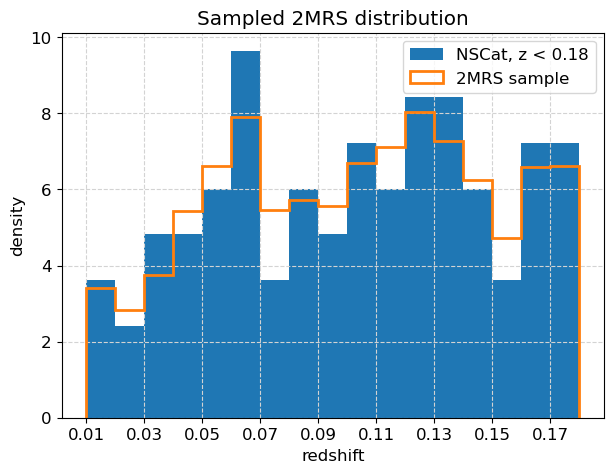

In [25]:
plt.title("Sampled 2MRS distribution")
plt.hist(nscat["z"], bins=17, range=[0.01, 0.18], density=True, label='NSCat, z < 0.18')
plt.hist(two_mrs_nscat["z"], bins=17, range=[0.01, 0.18], density=True, histtype='step', linewidth=2, label='2MRS sample')
plt.xlabel("redshift")
plt.ylabel("density")
plt.xticks(edges[::2])
plt.legend()
plt.show()

In [26]:
def generate_mock_subsamples(source_catalog, accepted_indices, target_sample_size, num_mocks=100):
    """
    Generates independent subsamples from the accepted rejection-sampled pool
    to match the exact size of the target dataset.
    
    Parameters:
    -----------
    source_catalog : dict or structure
        Your original full dataset (containing RA, DEC, redshifts, overdensities, etc.)
    accepted_indices : numpy.ndarray
        The indices returned by the rejection sampling function.
    target_sample_size : int
        The exact number N of galaxies to draw for each mock
    num_mocks : int
        The number of realizations to generate (100).
        
    Returns:
    --------
    mocks : list of dicts
        A list containing 100 independent mock catalogs.
    """
    mocks = []
    total_available = len(accepted_indices)
    
    if total_available < target_sample_size:
        raise ValueError(f"Not enough accepted galaxies ({total_available}) to draw samples of size {target_sample_size}.")
        
    print(f"Generating {num_mocks} independent mocks of size {target_sample_size} from a pool of {total_available} galaxies...")

    for i in range(num_mocks):
        # Randomly choose N unique indices from our pool of accepted galaxies
        # replace=False ensures we don't pick the same galaxy twice within a single mock
        subsampled_indices = np.random.choice(accepted_indices, size=target_sample_size, replace=False)
        
        # Extract the galaxy data for this specific mock realization
        # (Assuming source_catalog has a 'redshift' and 'overdensity' array/column)
        mock_data = {
            'mock_id': i,
            'z': source_catalog['z'][subsampled_indices],
            'ovdvalue': source_catalog['ovdvalue'][subsampled_indices] 
        }
        
        mocks.append(mock_data)
        
    print("Done! All 100 mock catalogs successfully generated.")
    return mocks

In [27]:
two_mrs_mocks = generate_mock_subsamples(
    source_catalog=two_mrs_nscat,
    accepted_indices=two_mrs_accepted,
    target_sample_size=len(ns_lowz["z"]),
    )

Generating 100 independent mocks of size 85 from a pool of 9776 galaxies...
Done! All 100 mock catalogs successfully generated.


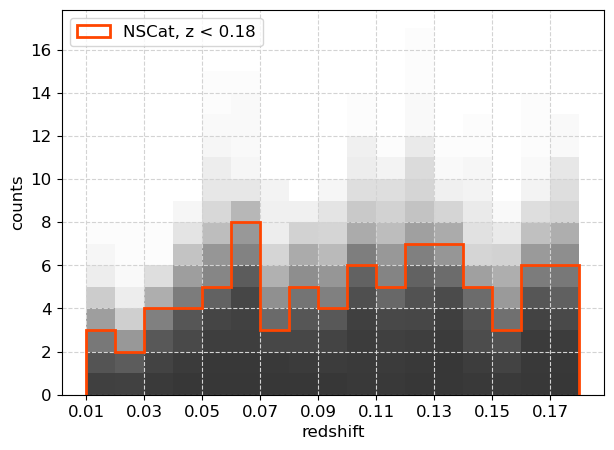

In [28]:
for m in two_mrs_mocks:
    plt.hist(m['z'], bins=17, range=[0.01, 0.18], color='k', alpha=0.01)
plt.hist(nscat["z"], bins=17, range=[0.01, 0.18], label='NSCat, z < 0.18', histtype='step', color='orangered', linewidth=2)
plt.xlabel("redshift")
plt.ylabel("counts")
plt.xticks(edges[::2])
plt.legend()
plt.show()

In [29]:
def plot_mock_vs_real_overdensities(mocks, real_catalog, nbins=16, ovd_range=(-1.0, 3.0), figsize=(7, 5)):
    """
    Plots a peak-normalized 2D density grid of mock count distributions 
    and overlays the real catalog counts with custom asymmetric error bars.
    
    Parameters:
    -----------
    mocks : list of dicts/DataFrames
        The list of generated mock catalogs (each must contain 'ovdvalue').
    real_catalog : pandas.DataFrame or dict
        The real data catalog (must contain 'ovdvalue' and 'z').
    nbins : int, optional
        Number of bins along the overdensity axis. Default is 16.
    ovd_range : tuple, optional
        The min and max range for the overdensity bins. Default is (-1.0, 3.0).
    figsize : tuple, optional
        The dimensions of the output plot. Default is (7, 5).
    """
    # --- Step 1: Define Bins and Setup Arrays ---
    bin_edges = np.linspace(ovd_range[0], ovd_range[1], nbins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # --- Step 2: Bin the Mocks ---
    num_mocks = len(mocks)
    mock_counts = np.zeros((num_mocks, nbins))
    for i, mock in enumerate(mocks):
        counts, _ = np.histogram(mock['ovdvalue'], bins=bin_edges)
        mock_counts[i, :] = counts

    max_count = int(np.max(mock_counts)) + 2
    y_edges = np.arange(0, max_count + 1, 1)
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    density_grid = np.zeros((len(y_centers), nbins))

    for b in range(nbins):
        counts_in_bin = mock_counts[:, b]
        hist_y, _ = np.histogram(counts_in_bin, bins=y_edges, density=True)
        density_grid[:, b] = hist_y

    # Normalize each column individually so the peak value is always 1.0
    cmap = plt.get_cmap('Blues', lut=10)
    normalized_density_grid = np.zeros_like(density_grid)
    for b in range(nbins):
        col_max = np.max(density_grid[:, b])
        if col_max > 0:
            normalized_density_grid[:, b] = density_grid[:, b] / col_max
        else:
            normalized_density_grid[:, b] = 0.0

    # --- Step 3: Bin the Real Data ---
    real_ovd_values = np.asarray(real_catalog['ovdvalue'])
    real_counts, _ = np.histogram(real_ovd_values, bins=bin_edges)

    # Calculate custom asymmetric errors for non-zero bins
    n = real_counts[real_counts > 0]
    real_yerr = np.zeros((2, len(real_counts)))
    if len(n) > 0:
        real_yerr[:, real_counts > 0] = np.array([
            n - n * (1 - 1 / (9 * n) - 1 / (3 * np.sqrt(n)))**3, 
            n + np.sqrt(n + 0.75) + 1 - n
        ])

    # --- Step 4: Plotting ---
    plt.figure(figsize=figsize)

    # Plot using the locally normalized grid
    plt.pcolormesh(
        bin_edges, 
        y_edges, 
        normalized_density_grid, 
        cmap=cmap, 
        shading='flat',
        vmin=0.0,
        vmax=1.0  
    )

    # Customize the colorbar to reflect relative probability within the bin
    plt.colorbar(label='Relative Probability within each bin')

    # Overlay real data with horizontal (bin width) and vertical custom error bars
    plt.errorbar(
        bin_centers, 
        real_counts,
        xerr=[bin_centers - bin_edges[:-1], bin_edges[1:] - bin_centers],
        yerr=real_yerr, 
        color='crimson', 
        linestyle='None',
        marker='o',
        label=f"NSCat Data ({len(real_ovd_values)} Galaxies)",
        zorder=5
    )

    plt.xlim(ovd_range)
    plt.ylim(0, max_count)
    plt.xlabel('Cumulative overdensity (ovdvalue)', fontsize=12)
    plt.ylabel('Number of Galaxies per Bin', fontsize=12)
    plt.title('Binned Overdensity: Real Catalog vs. Mock Distributions', fontsize=13)
    plt.legend(fontsize=11, loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_mock_vs_real_overdensities_smooth(mocks, real_catalog, nbins=16, ovd_range=(-1.0, 3.0), sigma_y=1.5, figsize=(7, 5)):
    """
    Plots a column-normalized, vertically smoothed 2D density grid of mock count 
    distributions and overlays the real catalog counts with custom asymmetric error bars.
    
    Parameters:
    -----------
    sigma_y : float, optional
        Standard deviation for the vertical Gaussian smoothing kernel (in units of count bins).
        A value of 1.0 to 2.0 usually yields a clean, smooth gradient without washing out features.
    """
    # --- Step 1: Define Bins and Setup Arrays ---
    bin_edges = np.linspace(ovd_range[0], ovd_range[1], nbins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # --- Step 2: Bin the Mocks ---
    num_mocks = len(mocks)
    mock_counts = np.zeros((num_mocks, nbins))
    for i, mock in enumerate(mocks):
        counts, _ = np.histogram(mock['ovdvalue'], bins=bin_edges)
        mock_counts[i, :] = counts

    max_count = int(np.max(mock_counts)) + 5  # Added breathing room for smoothed tails
    y_edges = np.arange(0, max_count + 1, 1)
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    density_grid = np.zeros((len(y_centers), nbins))

    for b in range(nbins):
        counts_in_bin = mock_counts[:, b]
        hist_y, _ = np.histogram(counts_in_bin, bins=y_edges, density=True)
        density_grid[:, b] = hist_y

    # --- NEW: Apply vertical smoothing to each column ---
    # Axis=0 applies the Gaussian filter strictly vertically within each overdensity bin
    smoothed_density_grid = gaussian_filter1d(density_grid, sigma=sigma_y, axis=0, mode='nearest')

    # Normalize each column individually so the peak value is always 1.0
    cmap = plt.get_cmap('Blues')  # Drop 'lut=10' for a continuous, smoother gradient mesh
    normalized_density_grid = np.zeros_like(smoothed_density_grid)
    for b in range(nbins):
        col_max = np.max(smoothed_density_grid[:, b])
        if col_max > 0:
            normalized_density_grid[:, b] = smoothed_density_grid[:, b] / col_max
        else:
            normalized_density_grid[:, b] = 0.0

    # --- Step 3: Bin the Real Data ---
    real_ovd_values = np.asarray(real_catalog['ovdvalue'])
    real_counts, _ = np.histogram(real_ovd_values, bins=bin_edges)

    # Calculate custom asymmetric errors for non-zero bins
    n = real_counts[real_counts > 0]
    real_yerr = np.zeros((2, len(real_counts)))
    if len(n) > 0:
        real_yerr[:, real_counts > 0] = np.array([
            n - n * (1 - 1 / (9 * n) - 1 / (3 * np.sqrt(n)))**3, 
            n + np.sqrt(n + 0.75) + 1 - n
        ])

    # --- Step 4: Plotting ---
    plt.figure()

    # Plot using the locally normalized, smoothed grid
    plt.pcolormesh(
        bin_edges, 
        y_edges, 
        normalized_density_grid, 
        cmap=cmap, 
        shading='flat',
        vmin=0.0,
        vmax=1.0  
    )

    plt.colorbar(label='Relative Probability within each bin')

    # Overlay real data with horizontal (bin width) and vertical custom error bars
    plt.errorbar(
        bin_centers, 
        real_counts,
        xerr=[bin_centers - bin_edges[:-1], bin_edges[1:] - bin_centers],
        yerr=real_yerr, 
        color='crimson', 
        linestyle='None',
        marker='o',
        label=f"NSCat [BOSS masked] ({len(real_ovd_values)} Galaxies)",
        zorder=5
    )

    plt.xlim(ovd_range)
    plt.ylim(0, max_count)
    plt.xlabel('Cumulative overdensity')
    plt.ylabel('Number of Galaxies per Bin')
    plt.title('Binned Overdensity: Real Catalog vs. Mock Distributions')
    plt.legend(loc='upper right')

    plt.tight_layout()

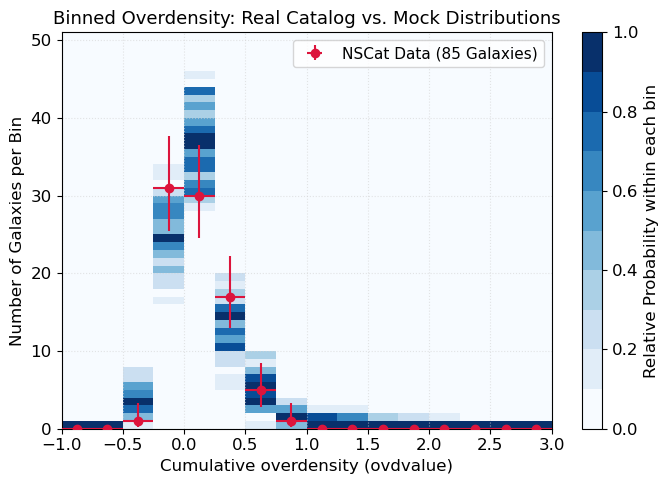

In [31]:
plot_mock_vs_real_overdensities(
    mocks=two_mrs_mocks, 
    real_catalog=ns_lowz, 
    nbins=16, 
    ovd_range=(-1.0, 3.0)
)

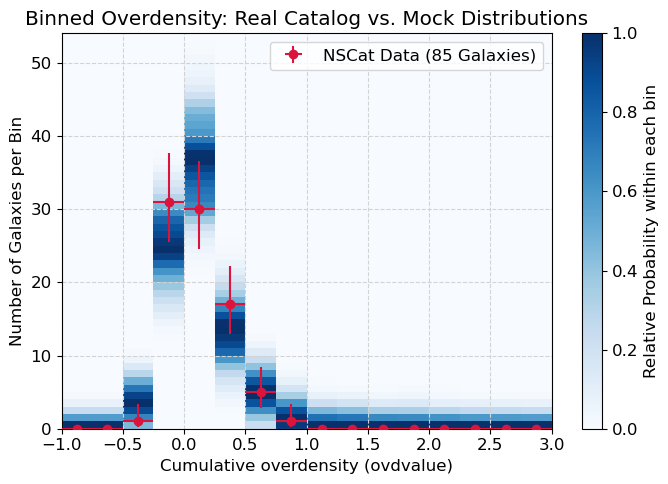

In [32]:
plot_mock_vs_real_overdensities_smooth(
    mocks=two_mrs_mocks, 
    real_catalog=ns_lowz, 
    nbins=16, 
    ovd_range=(-1.0, 3.0)
)

In [33]:
def analyze_ks_distributions(mocks, real_catalog):
    """
    Performs a two-tier Kolmogorov-Smirnov (K-S) test analysis:
    1. Compares the real catalog against all 100 mocks (Data vs Mock).
    2. Compares Mock #1 against all other mocks (Mock vs Mock Control Group).
    
    Parameters:
    -----------
    mocks : list of dicts/DataFrames
        The list of generated mock catalogs (each must contain 'ovdvalue').
    real_catalog : pandas.DataFrame or dict
        The real data catalog (must contain 'ovdvalue').
        
    Returns:
    --------
    p_values_data : list
        The 100 p-values from comparing the real data to each mock.
    p_values_control : list
        The 99 p-values from comparing Mock #1 to all other mocks.
    """
    # Extract the real overdensities
    real_ovd = np.asarray(real_catalog['ovdvalue'])
    
    p_values_data = []
    # Tier 1: Compare real data against each of your mocks
    for mock in mocks:
        mock_ovd = mock['ovdvalue']
        _, p_val = sps.ks_2samp(real_ovd, mock_ovd)
        p_values_data.append(p_val)
        
    p_values_control = []
    mock1_ovd = mocks[1]['ovdvalue']
    # Tier 2: Compare Mock #1 to Mocks 2..100 (Control Group)
    for mock in mocks[1:]:
        mock_ovd = mock['ovdvalue']
        _, p_val = sps.ks_2samp(mock1_ovd, mock_ovd)
        p_values_control.append(p_val)
        
    print(f"--- K-S Test Distribution Summary ---")
    print(f"Mean Data-vs-Mock p-value:  {np.mean(p_values_data):.3f}")
    print(f"Mean Control Mock-vs-Mock p-value: {np.mean(p_values_control):.3f}")
    
    return p_values_data, p_values_control

--- K-S Test Distribution Summary ---
Mean Data-vs-Mock p-value:  0.614
Mean Control Mock-vs-Mock p-value: 0.521


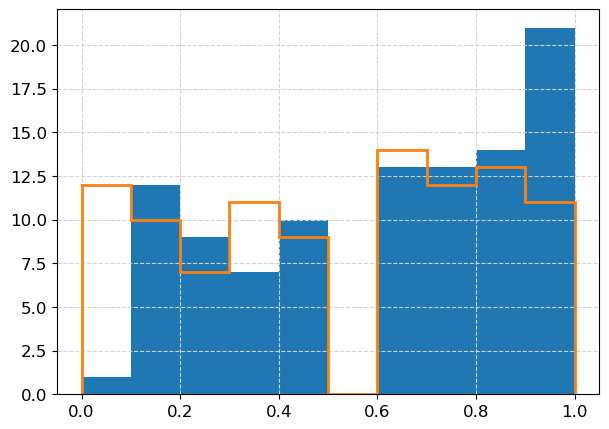

In [34]:
pv_data, pv_control = analyze_ks_distributions(two_mrs_mocks, ns_lowz)

plt.hist(pv_data, bins=10, range=[0, 1])
plt.hist(pv_control, bins=10, histtype='step', range=[0, 1], lw=2)

plt.show()

### 6dF vs NSCat

In [35]:
six_df_raw = np.load(DATA_DIR / "6df" / "6df-clean.npz")

six_df = pd.DataFrame(np.array([six_df_raw["ra"], six_df_raw["dec"], six_df_raw["z"]]).T, columns=["RA", "Dec", "z"])

six_df.head()

,RA,Dec,z
0,0.010750,-23.368028,0.06660
1,0.013667,-36.084444,0.06044
2,0.013667,-36.084444,0.06038
3,0.017583,-52.365861,0.09181
4,0.017750,-50.309556,0.06617


#### Choose the sources inside the mask

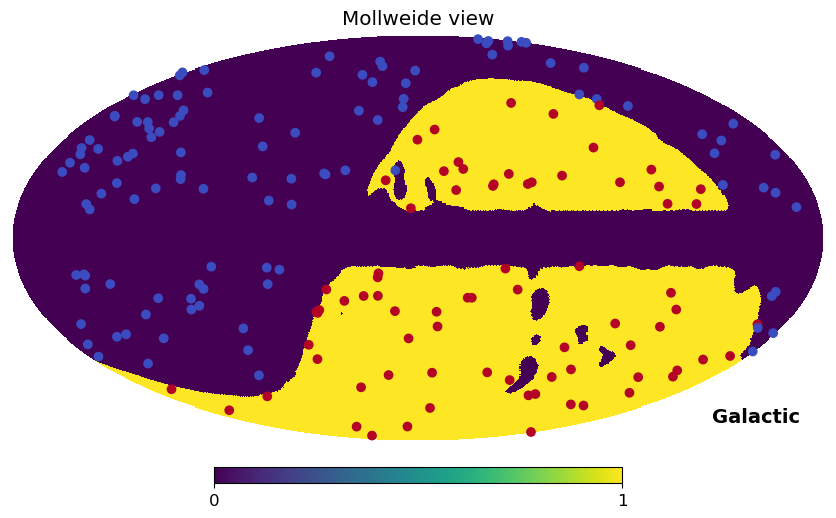

In [36]:
six_df_mask = np.load(DATA_DIR / "6df" / "6df_mask.npy")

nscat_pxnum = hp.ang2pix(128, nscat["RA"], nscat["Dec"], lonlat=True)
nscat["in_6df"] = six_df_mask[nscat_pxnum]

hp.mollview(six_df_mask, coord=['C', 'G'])
hp.projscatter(nscat["RA"], nscat["Dec"], lonlat=True, c=nscat['in_6df'], cmap='coolwarm', coord='C')

nscat_6df_lowz = nscat.query("z < 0.18 & in_6df")

In [37]:
ns_hist, edges = np.histogram(nscat_6df_lowz["z"], bins=17, range=[0.01, 0.18], density=True)
z_centers = 0.5 * (edges[1:] + edges[:-1])

# smooth
nz = gaussian_filter1d(ns_hist, sigma=1.0)

# normalize
nz /= np.trapz(nz, z_centers)

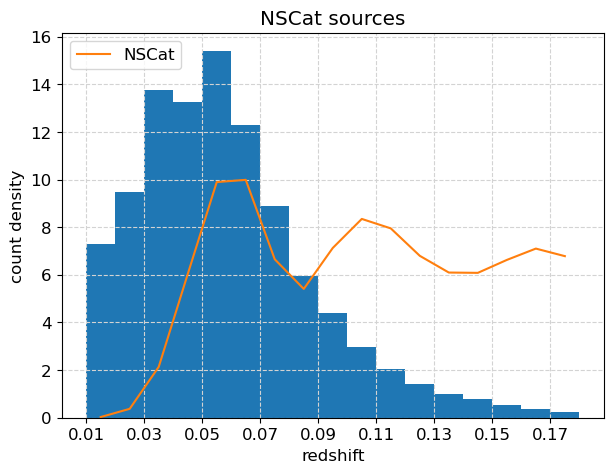

In [38]:
plt.hist(six_df["z"], bins=17, range=[0.01, 0.18], density=True)
plt.plot(z_centers, nz, label='NSCat')
plt.title("NSCat sources")
plt.xlabel("redshift")
plt.xticks(edges[::2])
plt.ylabel("count density")
plt.legend(loc=2)
plt.show()

In [39]:
six_df_accepted = rejection_sample_from_target_dataset(
    source_redshifts=np.array(six_df["z"]),
    target_redshifts=np.array(nscat_6df_lowz["z"]),
    z_min=0.01, z_max=0.18)

--- Dataset-to-Dataset Rejection Sampling ---
Target galaxies in window: 35
Source galaxies in window: 111819
Accepted source galaxies:  4557
Sampling Efficiency:       4.08%


In [40]:
six_df_nscat = (six_df.iloc[six_df_accepted]).copy()

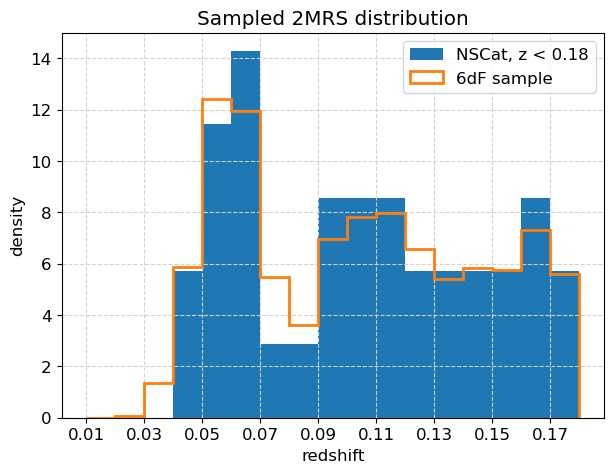

In [41]:
plt.title("Sampled 2MRS distribution")
plt.hist(nscat_6df_lowz["z"], bins=17, range=[0.01, 0.18], density=True, label='NSCat, z < 0.18')
plt.hist(six_df_nscat["z"], bins=17, range=[0.01, 0.18], density=True, histtype='step', linewidth=2, label='6dF sample')
plt.xlabel("redshift")
plt.ylabel("density")
plt.xticks(edges[::2])
plt.legend()
plt.show()

In [42]:
add_overdensity_values_to_catalog(six_df_nscat, overdensity_interpolator, nside=128)

Successfully calculated 'ovdvalue' for 4557 galaxies using the masked global grid.


In [43]:
six_df_mocks = generate_mock_subsamples(
    source_catalog=six_df_nscat,
    accepted_indices=six_df_accepted,
    target_sample_size=len(nscat_6df_lowz["z"]),
    )

Generating 100 independent mocks of size 36 from a pool of 4557 galaxies...
Done! All 100 mock catalogs successfully generated.


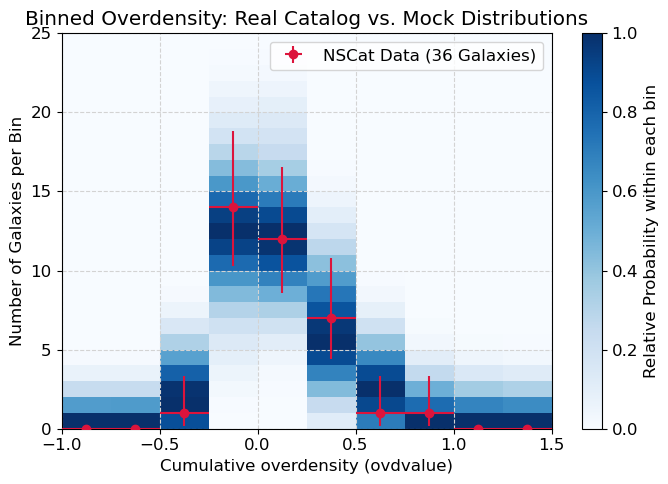

In [44]:
plot_mock_vs_real_overdensities_smooth(
    mocks=six_df_mocks, 
    real_catalog=nscat_6df_lowz, 
    nbins=10, 
    ovd_range=(-1.0, 1.5)
)

--- K-S Test Distribution Summary ---
Mean Data-vs-Mock p-value:  0.590
Mean Control Mock-vs-Mock p-value: 0.528


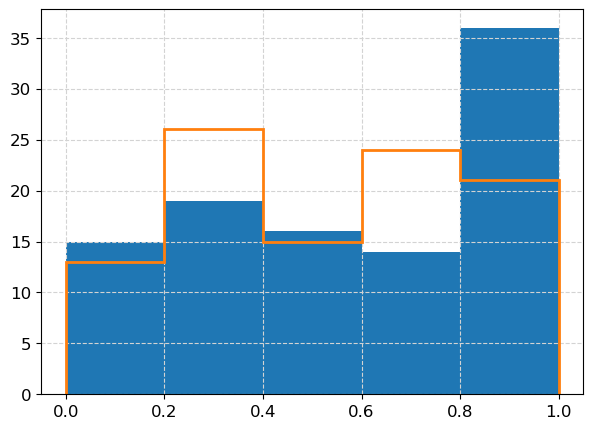

In [45]:
pv_data, pv_control = analyze_ks_distributions(six_df_mocks, nscat_6df_lowz)

plt.hist(pv_data, bins=5, range=[0, 1])
plt.hist(pv_control, bins=5, histtype='step', range=[0, 1], lw=2)

plt.show()

### BOSS (all redshifts!)

In [46]:
boss_raw = np.load(DATA_DIR / "sdss" / "boss-clean.npz")

boss = pd.DataFrame(np.array([boss_raw["ra"], boss_raw["dec"], boss_raw["z"]]).T, columns=["RA", "Dec", "z"])

boss.head()

,RA,Dec,z
0,195.211716,-0.505258,0.345888
1,225.586975,-0.046532,0.332610
2,225.513687,-0.190260,0.332531
3,195.151123,0.357886,0.384936
4,195.095917,-1.063041,0.248512


In [47]:
from astropy.coordinates import SkyCoord

MW_plane = SkyCoord(l=np.linspace(0, 360, 100), b=0.0, frame='galactic', unit='deg').galactic
theta_MW, phi_MW = np.pi/2 - MW_plane.b.rad, MW_plane.l.rad

EQ_plane = SkyCoord(ra=np.linspace(0, 360, 100), dec=0.0, frame='icrs', unit='deg').galactic
theta_EQ, phi_EQ = np.pi/2 - EQ_plane.b.rad, EQ_plane.l.rad

SG_plane = SkyCoord(sgl=np.linspace(0, 360, 100), sgb=0, frame='supergalactic', unit='deg').galactic
theta_SG, phi_SG = np.pi/2 - SG_plane.b.rad, SG_plane.l.rad

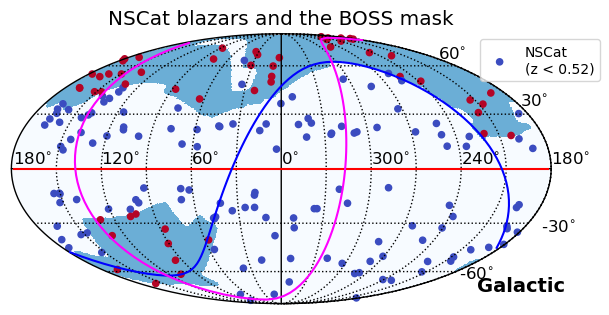

54


In [48]:
boss_df_mask = np.load(DATA_DIR / "sdss" / "sdss_mask.npy")

nscat_pxnum = hp.ang2pix(128, nscat["RA"], nscat["Dec"], lonlat=True)
nscat["in_boss"] = boss_df_mask[nscat_pxnum]

fig = plt.figure(figsize=(7, 4))
hp.mollview(1-boss_df_mask, coord=['C', 'G'], cmap='Blues_r', min=-1, max=1,
            cbar=False, hold=True,
            title='NSCat blazars and the BOSS mask')
hp.graticule()
hp.projscatter(nscat["RA"], nscat["Dec"], s=20,
               lonlat=True, c=nscat['in_boss'], cmap='coolwarm', coord='C',
               label="NSCat\n(z < 0.52)")

hp.projplot(theta_MW, phi_MW, color='red', coord='G')
hp.projplot(theta_EQ, phi_EQ, color='blue', coord='G')
hp.projplot(theta_SG, phi_SG, color='magenta', coord='G')

for l in range(0, 360, 60):
    hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$")
    if l == 180:
        hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$")
        
for m in range(-60, 90, 30):
    if m == 0:
        continue
    hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180),
                f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$")

plt.legend(loc=1, fontsize=10, bbox_to_anchor=(1.1, 1.0))
plt.savefig(f"{FIG_DIR}/NSCat_BOSS.pdf", bbox_inches='tight', pad_inches=0.05, dpi=300)
plt.show()

nscat_boss = nscat.query("in_boss")
print(len(nscat_boss))

In [49]:
ns_hist, edges = np.histogram(nscat_boss["z"], bins=17, range=[0.01, 0.52], density=True)
z_centers = 0.5 * (edges[1:] + edges[:-1])

# smooth
nz = gaussian_filter1d(ns_hist, sigma=1.0)

# normalize
nz /= np.trapz(nz, z_centers)

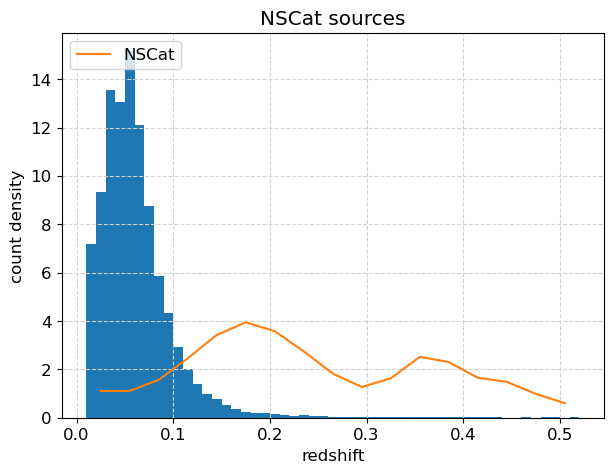

In [50]:
plt.hist(six_df["z"], bins=51, range=[0.01, 0.52], density=True)
plt.plot(z_centers, nz, label='NSCat')
plt.title("NSCat sources")
plt.xlabel("redshift")
plt.ylabel("count density")
plt.legend(loc=2)
plt.show()

In [51]:
boss_accepted = rejection_sample_from_target_dataset(
    source_redshifts=np.array(boss["z"]),
    target_redshifts=np.array(nscat_boss["z"]),
    z_min=0.01, z_max=0.52)

--- Dataset-to-Dataset Rejection Sampling ---
Target galaxies in window: 53
Source galaxies in window: 462107
Accepted source galaxies:  37607
Sampling Efficiency:       8.14%


In [52]:
boss_nscat = (boss.iloc[boss_accepted]).copy()

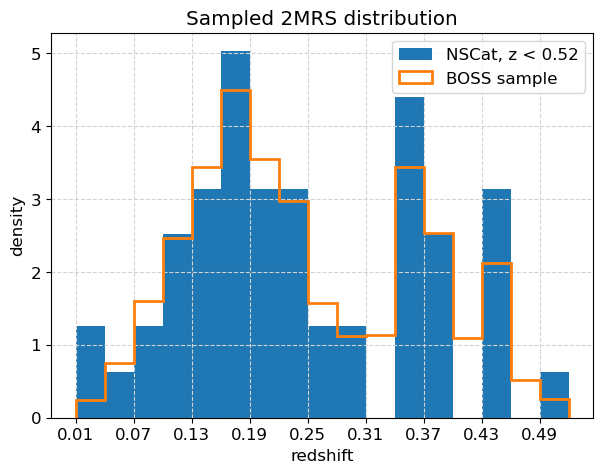

In [53]:
plt.title("Sampled 2MRS distribution")
plt.hist(nscat_boss["z"], bins=17, range=[0.01, 0.52], density=True, label='NSCat, z < 0.52')
plt.hist(boss_nscat["z"], bins=17, range=[0.01, 0.52], density=True, histtype='step', linewidth=2, label='BOSS sample')
plt.xlabel("redshift")
plt.ylabel("density")
plt.xticks(edges[::2])
plt.legend()
plt.show()

In [54]:
add_overdensity_values_to_catalog(boss_nscat, overdensity_interpolator, nside=128)

Successfully calculated 'ovdvalue' for 37607 galaxies using the masked global grid.


In [55]:
boss_mocks = generate_mock_subsamples(
    source_catalog=boss_nscat,
    accepted_indices=boss_accepted,
    target_sample_size=len(nscat_boss["z"]),
    )

Generating 100 independent mocks of size 54 from a pool of 37607 galaxies...
Done! All 100 mock catalogs successfully generated.


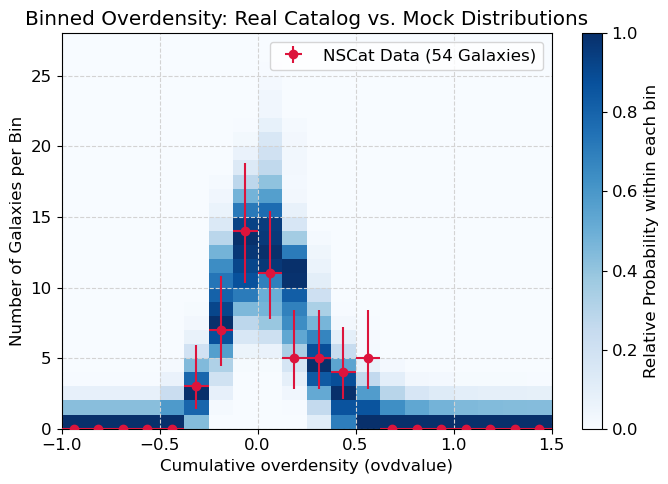

In [58]:
set_plotting_defaults()
plot_mock_vs_real_overdensities_smooth(
    mocks=boss_mocks, 
    real_catalog=nscat_boss, 
    nbins=20, 
    ovd_range=(-1.0, 1.5),
    sigma_y=1.0,
    figsize=(7, 4)
)
plt.savefig(FIG_DIR/"BOSS_dist_comp.pdf")
plt.show()

--- K-S Test Distribution Summary ---
Mean Data-vs-Mock p-value:  0.667
Mean Control Mock-vs-Mock p-value: 0.743


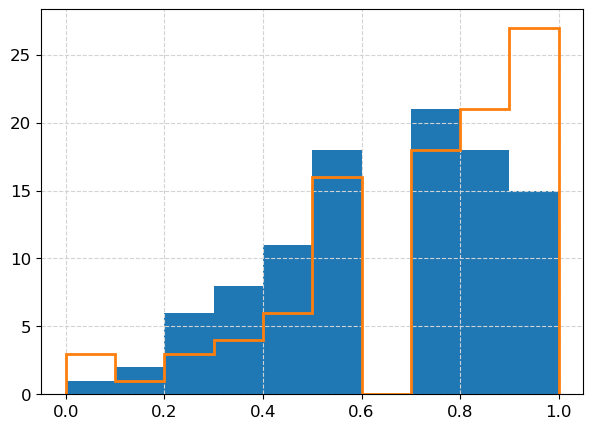

In [ ]:
pv_data, pv_control = analyze_ks_distributions(boss_mocks, nscat_boss)

plt.hist(pv_data, bins=10, range=[0, 1])
plt.hist(pv_control, bins=10, histtype='step', range=[0, 1], lw=2)

plt.show()